# Практична робота 7.1. Розпізнавання дорожніх знаків

Мета роботи — навчити модель розрізняти знаки обмеження швидкості 30 і 50 км/год та порівняти модель з одним нейроном із мережами, що мають приховані шари.

In [1]:
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense

tf.keras.utils.set_random_seed(42)

## 1. Підготовка даних

Використовую зображення з теки `subset_homework`: клас 0 — знак 30 км/год, клас 1 — знак 50 км/год.

In [2]:
data_dir = Path('data/subset_homework')

images, labels = [], []
for class_id in (0, 1):
    files = sorted((data_dir / f'class_id_{class_id}').glob('*.jpg'))
    print(f'Клас {class_id}: {len(files)} зображень')
    for file in files:
        images.append(np.array(Image.open(file).convert('L')))
        labels.append(class_id)

images = np.array(images)
labels = np.array(labels)
print('Усього:', len(images), '| розмір:', images[0].shape)

Клас 0: 2220 зображень
Клас 1: 2250 зображень
Усього: 4470 | розмір: (28, 28)


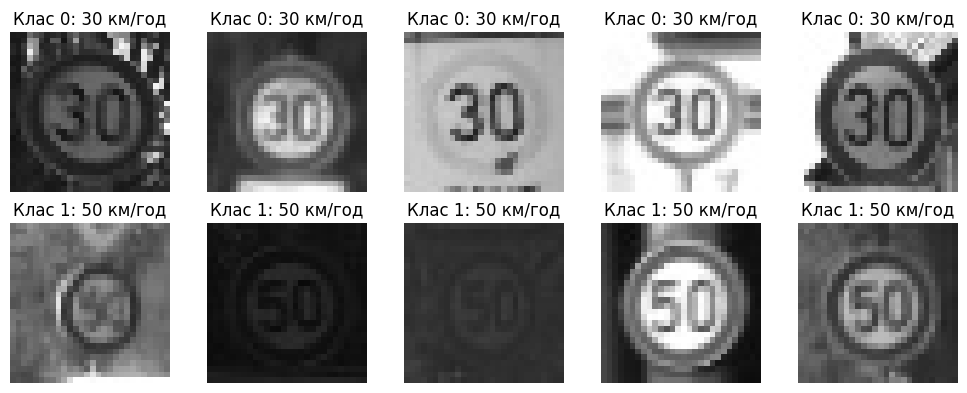

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for class_id in (0, 1):
    indexes = np.where(labels == class_id)[0]
    for ax, idx in zip(axes[class_id], np.random.choice(indexes, 5, replace=False)):
        ax.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'Клас {class_id}: {30 + 20 * class_id} км/год')
        ax.axis('off')
plt.tight_layout()
plt.show()

Кожне зображення 28 × 28 перетворюю на вектор із 784 значень і ділю значення пікселів на 255. Дані поділяю на навчальну, перевірочну й тестову вибірки. На перевірочній вибираю модель, а тестову залишаю для підсумкової оцінки.

In [4]:
X = images.reshape(len(images), -1).astype('float32') / 255.0
y = labels.astype('float32')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85,
    stratify=y_trainval, random_state=42
)
print('Форма даних:', X.shape)
print('Навчальні:', len(X_train), '| перевірочні:', len(X_val), '| тестові:', len(X_test))

Форма даних: (4470, 784)
Навчальні: 3128 | перевірочні: 671 | тестові: 671


## 2. Модель з одним нейроном

Спочатку навчаю модель з одним лінійним нейроном і без прихованих шарів. Якщо її вихід більший за 0,5, відношу зображення до класу 1.

In [5]:
inputs = Input(shape=(X_train.shape[1],))
outputs = Dense(1, activation='linear')(inputs)
single_neuron = Model(inputs, outputs)
single_neuron.compile(optimizer='adam', loss='mean_squared_error')

history_one = single_neuron.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=25, batch_size=32, verbose=0
)
one_train = accuracy_score(y_train, single_neuron.predict(X_train, verbose=0).ravel() > 0.5)
one_val = accuracy_score(y_val, single_neuron.predict(X_val, verbose=0).ravel() > 0.5)
print(f'Один нейрон: навчальна точність {one_train:.2%}, перевірочна {one_val:.2%}')

Один нейрон: навчальна точність 95.84%, перевірочна 95.68%


## 3. Мережі з прихованими шарами

Далі навчаю дві мережі: з одним прихованим шаром на 64 нейрони та з двома шарами на 64 і 32 нейрони. Вихідний нейрон має сигмоїдну активацію. Навчання зупиняю, якщо перевірочна функція втрат не покращується протягом 12 епох.

In [6]:
architectures = {
    '64 нейрони': (64,),
    '64 і 32 нейрони': (64, 32),
}
models, histories, val_scores = {}, {}, {}

for name, sizes in architectures.items():
    inputs = Input(shape=(X_train.shape[1],))
    x = inputs
    for size in sizes:
        x = Dense(size, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=100, batch_size=32, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=12, restore_best_weights=True
        )]
    )
    train_pred = model.predict(X_train, verbose=0).ravel() > 0.5
    val_pred = model.predict(X_val, verbose=0).ravel() > 0.5
    train_score = accuracy_score(y_train, train_pred)
    val_scores[name] = accuracy_score(y_val, val_pred)
    models[name], histories[name] = model, history
    print(f'{name}: навчальна {train_score:.2%}, перевірочна {val_scores[name]:.2%}, епох {len(history.history["loss"])}')

64 нейрони: навчальна 98.69%, перевірочна 97.47%, епох 83
64 і 32 нейрони: навчальна 98.50%, перевірочна 98.06%, епох 47


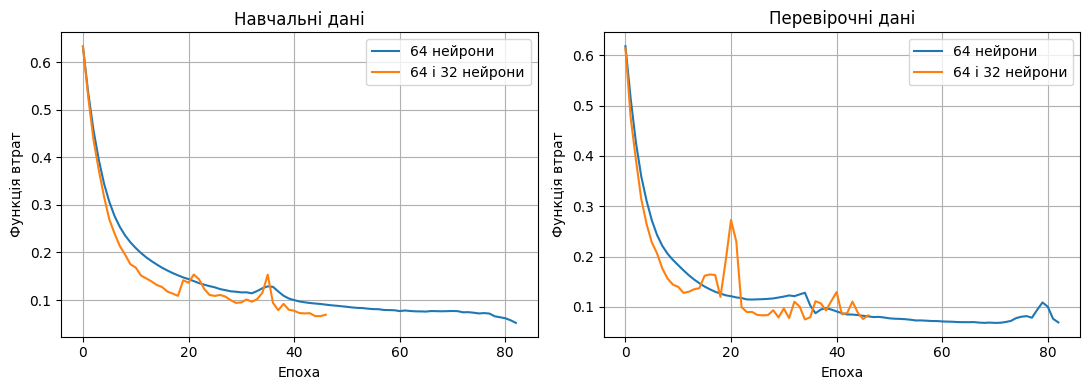

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, history in histories.items():
    axes[0].plot(history.history['loss'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)
axes[0].set_title('Навчальні дані')
axes[1].set_title('Перевірочні дані')
for ax in axes:
    ax.set_xlabel('Епоха')
    ax.set_ylabel('Функція втрат')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

На графіках видно, що функція втрат загалом зменшується. Обираю мережу за точністю на перевірочних даних, а потім оцінюю її на тестових.

In [8]:
best_name = max(val_scores, key=val_scores.get)
best_model = models[best_name]

one_test_pred = single_neuron.predict(X_test, verbose=0).ravel() > 0.5
best_predictions = best_model.predict(X_test, verbose=0).ravel() > 0.5
one_test = accuracy_score(y_test, one_test_pred)
best_test = accuracy_score(y_test, best_predictions)

print(f'Найкраща з випробуваних мереж: {best_name} (перевірочна точність {val_scores[best_name]:.2%})')
print(f'Один нейрон, тестова точність: {one_test:.2%}')
print(f'Обрана мережа, тестова точність: {best_test:.2%}')

Найкраща з випробуваних мереж: 64 і 32 нейрони (перевірочна точність 98.06%)
Один нейрон, тестова точність: 94.19%
Обрана мережа, тестова точність: 96.57%


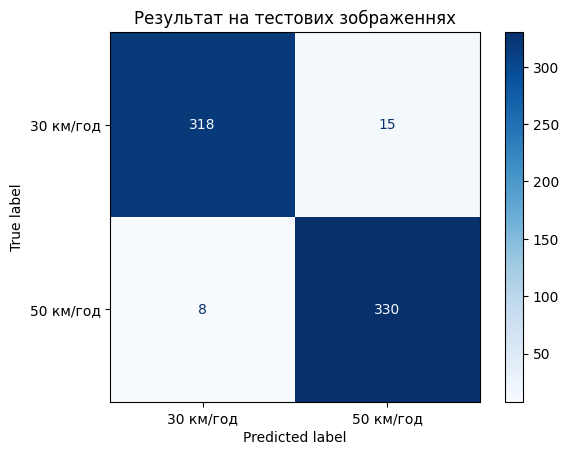

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test.astype(int), best_predictions.astype(int),
    display_labels=['30 км/год', '50 км/год'], cmap='Blues'
)
plt.title('Результат на тестових зображеннях')
plt.show()

## Висновок

In [ ]:
correct = int(np.sum(best_predictions == y_test))
print(f'Один нейрон: перевірочна точність {one_val:.2%}, тестова {one_test:.2%}.')
print(f'Найкраща з випробуваних мереж ({best_name}): перевірочна точність {val_scores[best_name]:.2%}, тестова {best_test:.2%}.')
print(f'На тестових даних правильно визначено {correct} із {len(y_test)} знаків.')

Один нейрон: перевірочна точність 95.68%, тестова 94.19%.
Найкраща з випробуваних мереж (64 і 32 нейрони): перевірочна точність 98.06%, тестова 96.57%.
На тестових даних правильно визначено 648 із 671 знаків.
Мережа з прихованими шарами дала вищу тестову точність, ніж модель з одним нейроном.


Мережа з прихованими шарами дала вищу тестову точність, ніж модель з одним нейроном